# Basic GDP Growth Models

Exploration of the **Solow-Swan growth model** and related concepts.
With this simple model, we can understand how capital accumulation, labor growth, the impact of technology and the impact on wage growth.

For a much more detailed and rigorous treatment of the Solow-Swan model and neoclassical growth theory, see [The Free MIT course on Economic Growth](https://ocw.mit.edu/courses/14-452-economic-growth-fall-2016/pages/lecture-notes/).


In [1]:
import matplotlib.pyplot as plt
import sys

sys.path.append("..")
from src import plots

In [2]:
# print(plt.style.available)
plt.style.use(["seaborn-v0_8", "seaborn-v0_8-darkgrid", "seaborn-v0_8-notebook"])

## Cobb-Douglas Production Function

The Cobb-Douglas production function is a widely used functional form in economics to represent the relationship between inputs (capital and labor) and output. It follow from applying Euler's theorem to a production function with constant returns to scale.

$$Y = A \cdot K^{\alpha} \cdot (E \cdot L)^{1-\alpha}$$

- $Y$: output, $K$: capital, $L$: labor, $E$: labor efficiency (technology)
- $A$: total factor productivity, $\alpha \in (0,1)$: capital share of output
- Constant returns to scale: $F(\lambda K, \lambda L) = \lambda F(K,L)$
- Diminishing marginal returns in each factor separately


In [3]:
def cobb_douglas(capital, labor, a=1, alpha=0.3, labor_efficiency=1, **kwargs):
    return a * (capital**alpha) * ((labor * labor_efficiency) ** (1 - alpha))

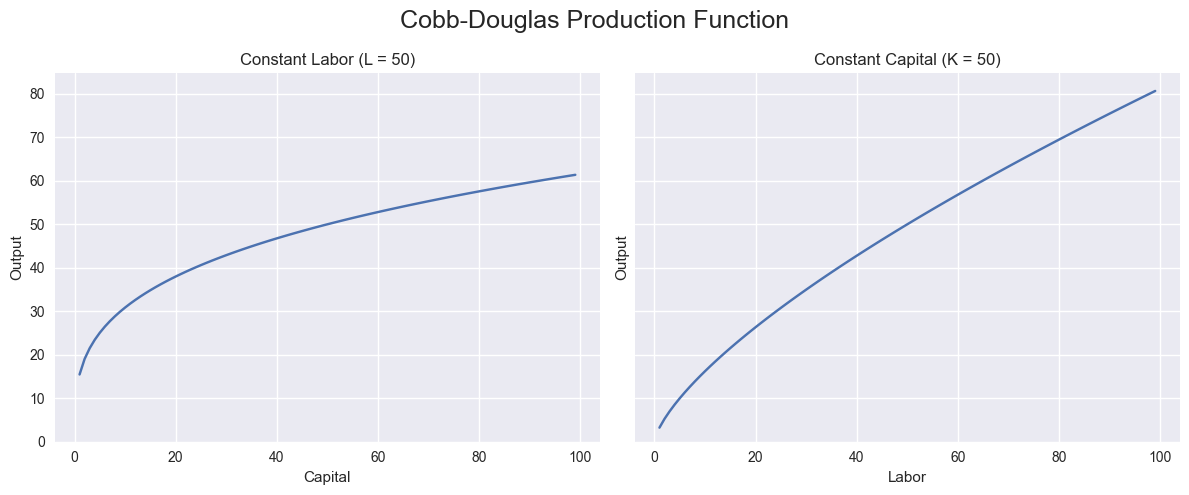

In [4]:
capital_values = range(1, 100)
labor_values = range(1, 100)

# constant labor
labor = 50
output_const_labor = [cobb_douglas(k, labor) for k in capital_values]

# constant capital
capital = 50
output_const_capital = [cobb_douglas(capital, l) for l in labor_values]

y_max = max(max(output_const_labor), max(output_const_capital))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

ax1.plot(capital_values, output_const_labor)
ax1.set_title("Constant Labor (L = 50)")
ax1.set_xlabel("Capital")
ax1.set_ylabel("Output")
ax1.set_ylim(0, y_max * 1.05)

ax2.plot(labor_values, output_const_capital)
ax2.set_title("Constant Capital (K = 50)")
ax2.set_xlabel("Labor")
ax2.set_ylabel("Output")
ax2.set_ylim(0, y_max * 1.05)

fig.suptitle("Cobb-Douglas Production Function", fontsize=18)
fig.tight_layout()

## Solow-Swan Growth Model

The economy saves a fraction $s$ of output and capital depreciates at rate $\delta$. The fundamental capital accumulation equation:

$$\dot{K} = sY - \delta K$$

**Steady state** ($\dot{K}=0$): setting investment equal to depreciation and solving for $K^*$:

$$K^* = \left(\frac{sA \cdot L^{1-\alpha}}{\delta}\right)^{\frac{1}{1-\alpha}}$$


In [5]:
def equilibrium_capital(labor, a=1, alpha=0.3, depreciation=0.05, savings_rate=0.2):
    return ((savings_rate * a * (labor ** (1 - alpha))) / depreciation) ** (
        1 / (1 - alpha)
    )

### Discrete-Time Capital Dynamics

In discrete time, the accumulation equation becomes:

$$K_{t+1} = (1-\delta)K_t + s \cdot Y_t$$


In [6]:
def time_step(
    capital,
    labor,
    a=1,
    alpha=0.3,
    depreciation=0.05,
    savings_rate=0.2,
    labor_efficiency=1,
):
    output = cobb_douglas(capital, labor, a, alpha, labor_efficiency=labor_efficiency)
    new_capital = (1 - depreciation) * capital + savings_rate * output
    return new_capital

### Convergence to Steady State

The Solow model predicts that regardless of initial capital $K_0$, the economy converges to $K^*$. Below we simulate starting from different fractions of the equilibrium capital.


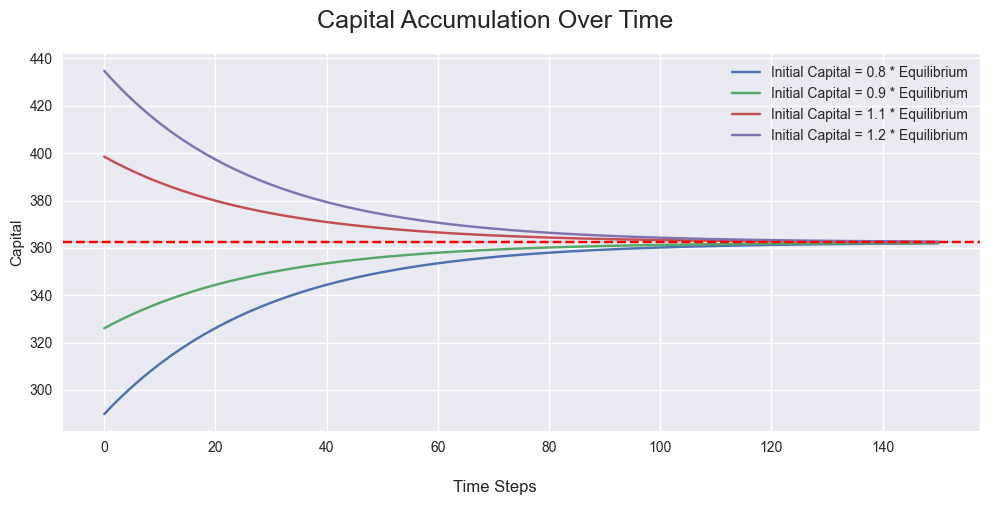

In [ ]:
# given initial capital and labor, simulate the economy
parameters = {
    "a": 1,
    "alpha": 0.3,
    "depreciation": 0.05,
    "savings_rate": 0.2,
}
initial_labor = 50
eq_capital = equilibrium_capital(initial_labor, **parameters)
data = {}
for factor in [0.8, 0.9, 1.1, 1.2]:
    initial_capital = eq_capital * factor
    capital_over_time = [initial_capital]
    for t in range(150):
        new_capital = time_step(capital_over_time[-1], initial_labor, **parameters)
        capital_over_time.append(new_capital)
    data[f"Initial Capital = {factor} * Equilibrium"] = capital_over_time

fig, axes = plots.plot_time_data(
    data, title="Capital Accumulation Over Time", y_label="Capital"
)
axes[0].axhline(eq_capital, color="red", linestyle="--", label="Equilibrium Capital")
plt.show()

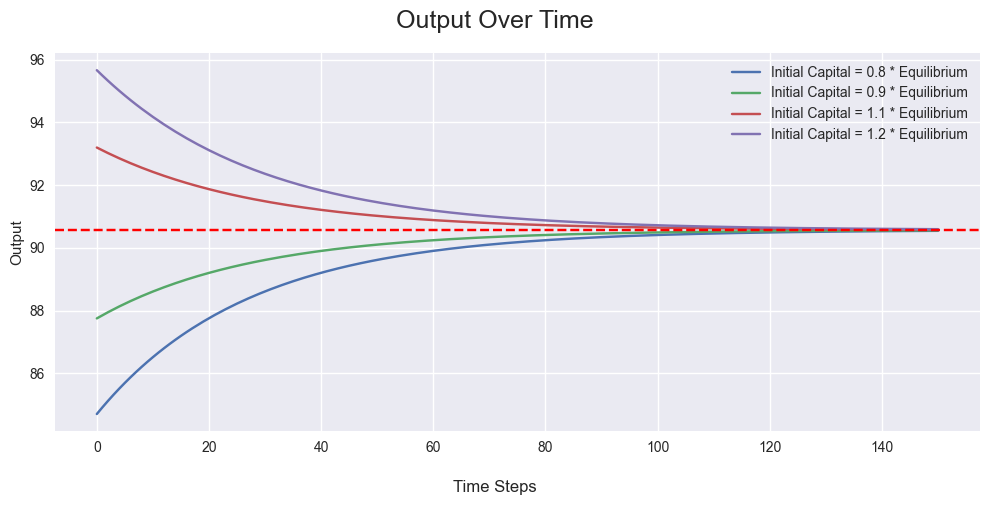

In [8]:
# Same but with production output instead of capital
data_output = {}
for factor, capital_over_time in data.items():
    output_over_time = [
        cobb_douglas(k, initial_labor, **parameters) for k in capital_over_time
    ]
    data_output[factor] = output_over_time


fig, axes = plots.plot_time_data(
    data_output, title="Output Over Time", y_label="Output"
)
axes[0].axhline(
    cobb_douglas(eq_capital, initial_labor, **parameters),
    color="red",
    linestyle="--",
    label="Equilibrium Output",
)
plt.show()

# Deviations from Steady State

Now that we have a way to simulate the dynamics of production, we can see what happens when we deviate from the steady state.

## Labor Growth

First, let's look at the case where labor grows at some rate for a limited time, and then stops growing.


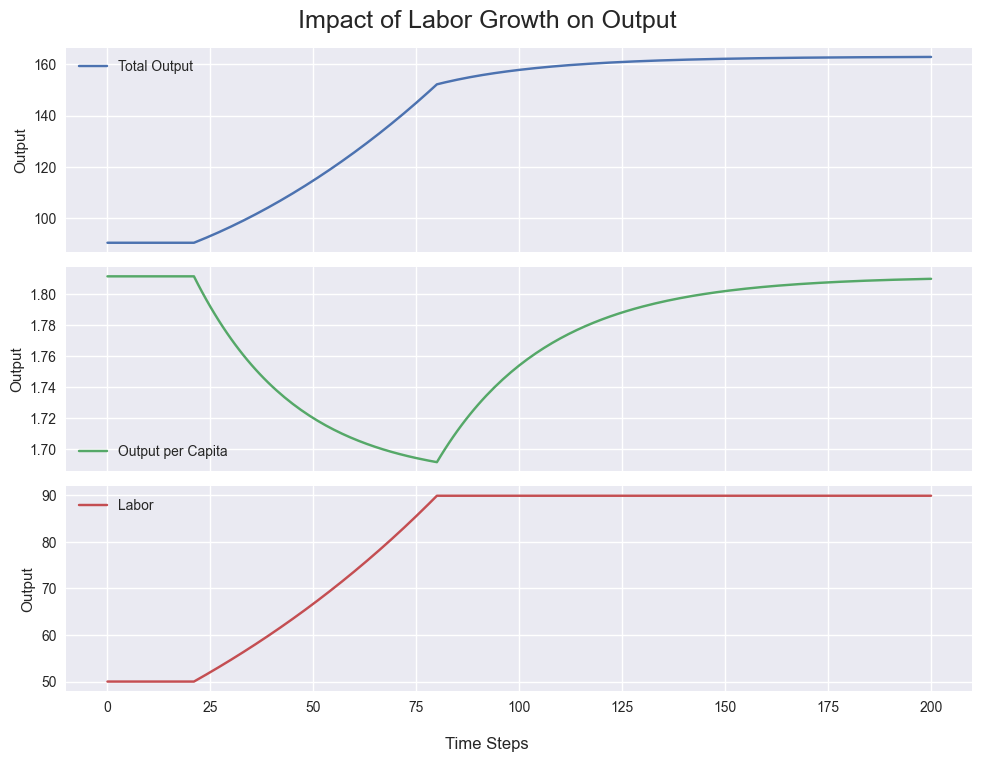

In [ ]:
# labor growth over time
labor_growth_rate = 0.01  # 1% growth per time step
initial_labor = 50
labor_over_time = [initial_labor]
initial_capital = equilibrium_capital(initial_labor, **parameters)
capital_over_time = [initial_capital]
initial_production = cobb_douglas(initial_capital, initial_labor, **parameters)
production_over_time = [initial_production]
production_per_capita_over_time = [initial_production / initial_labor]
for t in range(200):
    new_labor = (
        labor_over_time[-1] * (1 + labor_growth_rate)
        if t > 20 and t < 80
        else labor_over_time[-1]
    )
    labor_over_time.append(new_labor)
    new_capital = time_step(capital_over_time[-1], labor_over_time[-1], **parameters)
    capital_over_time.append(new_capital)
    new_production = cobb_douglas(new_capital, new_labor, **parameters)
    production_over_time.append(new_production)
    production_per_capita_over_time.append(new_production / new_labor)

fig, (ax1, ax2, ax3) = plots.plot_time_data(
    {
        "Total Output": production_over_time,
        "Output per Capita": production_per_capita_over_time,
        "Labor": labor_over_time,
    },
    title="Impact of Labor Growth on Output",
    y_label="Output",
    separate=True,
)

### Instantaneous Labor Shock

A one-time increase in $L$ dilutes capital per worker ($k = K/L$ drops), temporarily lowering per-capita output. The economy then converges to a new steady state with higher total $K$ but the same $k^*$.


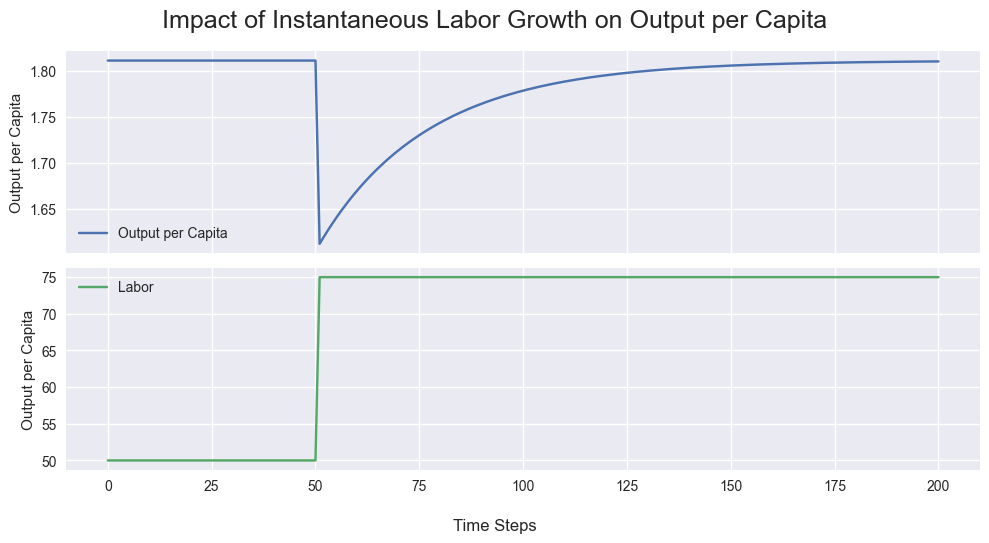

In [10]:
# simulation of instantaneous labor growth at a given step
labor_growth_time_step = 50
labor_growth_rate = 0.5  # 50% growth at the specified time step
initial_labor = 50
labor_over_time = [initial_labor]
initial_capital = equilibrium_capital(initial_labor, **parameters)
capital_over_time = [initial_capital]
initial_production = cobb_douglas(initial_capital, initial_labor, **parameters)
production_per_capita_over_time = [initial_production / initial_labor]
for t in range(200):
    if t == labor_growth_time_step:
        new_labor = labor_over_time[-1] * (1 + labor_growth_rate)
    else:
        new_labor = labor_over_time[-1]
    labor_over_time.append(new_labor)
    new_capital = time_step(capital_over_time[-1], new_labor, **parameters)
    capital_over_time.append(new_capital)
    new_production = cobb_douglas(new_capital, new_labor, **parameters)
    production_per_capita_over_time.append(new_production / new_labor)

fig, (ax1, ax2) = plots.plot_time_data(
    {
        "Output per Capita": production_per_capita_over_time,
        "Labor": labor_over_time,
    },
    title="Impact of Instantaneous Labor Growth on Output per Capita",
    y_label="Output per Capita",
    separate=True,
)

### Inverting the Production Function

Solving Cobb-Douglas for $L$ given target output $Y$:

$$L = \frac{1}{E}\left(\frac{Y}{A \cdot K^{\alpha}}\right)^{\frac{1}{1-\alpha}}$$


In [ ]:
def labor_from_production(
    production, capital, a=1, alpha=0.3, labor_efficiency=1, **kwargs
):
    return (production / (a * (capital**alpha))) ** (1 / (1 - alpha)) / labor_efficiency

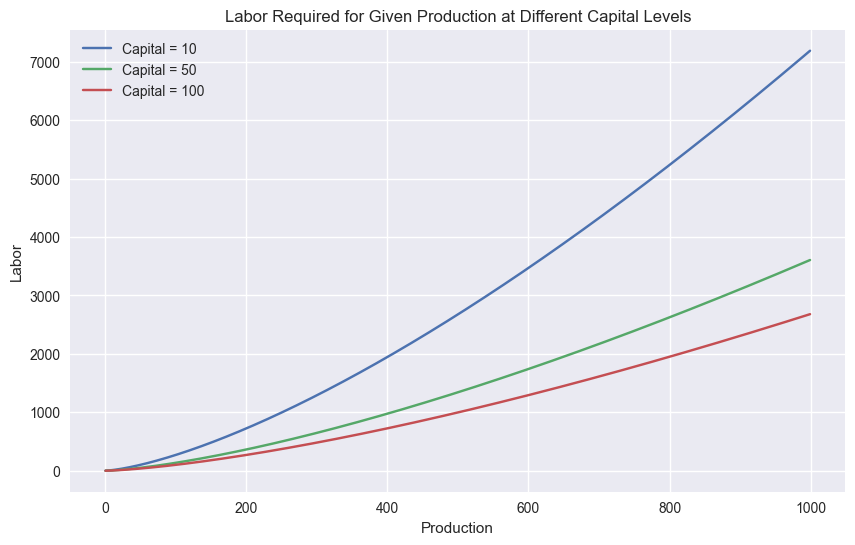

In [12]:
# plot labor from production as a function of production for a given values of capital
capital_values = [10, 50, 100]
production_values = range(1, 1000)
plt.figure(figsize=(10, 6))
for capital in capital_values:
    labor_values = [
        labor_from_production(p, capital, **parameters) for p in production_values
    ]
    plt.plot(production_values, labor_values, label=f"Capital = {capital}")
plt.xlabel("Production")
plt.ylabel("Labor")
plt.title("Labor Required for Given Production at Different Capital Levels")
plt.legend()
plt.show()

### Equilibrium Wage

Under perfect competition, profit is zero ($Y = wL + rK$). The wage equals the marginal product of labor:

$$w = \frac{\partial Y}{\partial L} = (1-\alpha)\frac{Y}{L}$$

Equivalently, given a capital rental rate $r$: $w = \frac{Y - rK}{L}$


In [13]:
def equilibrium_wage(
    capital, labor, a=1, alpha=0.3, labor_efficiency=1, capital_cost=0.1, **kwargs
):
    production = cobb_douglas(
        capital, labor, a, alpha, labor_efficiency=labor_efficiency
    )
    return (production - capital_cost * capital) / labor

## Labor-Augmenting Technological Progress

Technology enters the production function through labor efficiency $E$:

$$Y = A \cdot K^{\alpha} \cdot (E \cdot L)^{1-\alpha}$$

With $E$ growing at rate $g$, the Solow model predicts sustained growth in output per capita — unlike labor or capital accumulation alone, which only produce level effects.


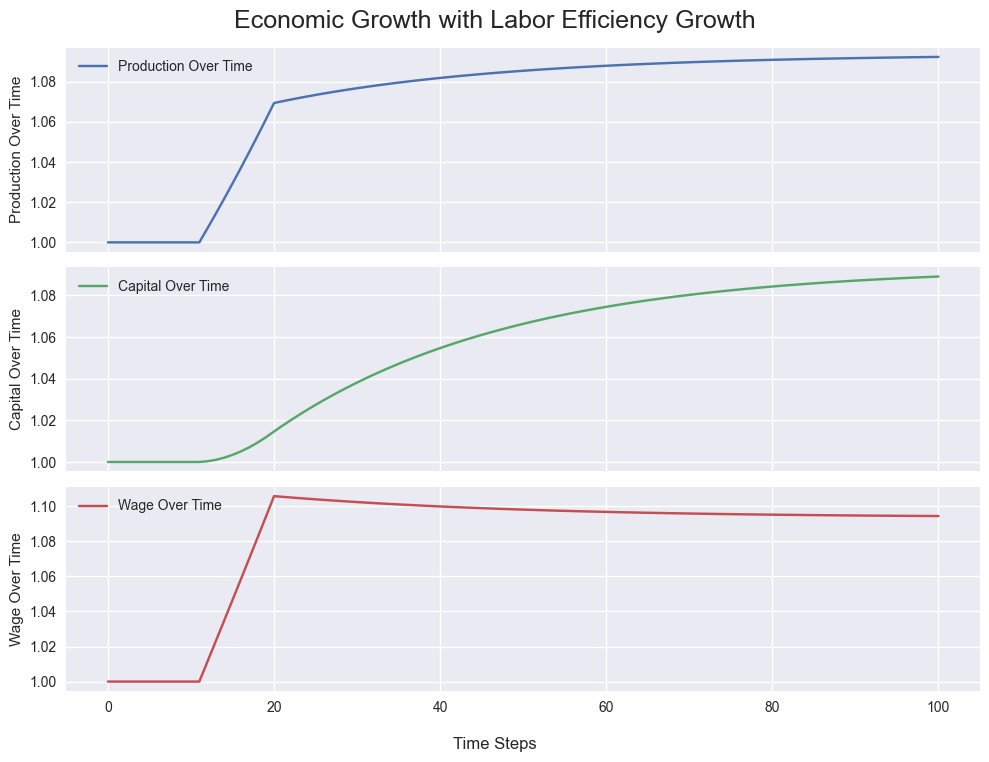

In [14]:
# labor efficiency growth step at time 10

labor_efficiency_growth_start_time_step = 10
labor_efficiency_growth_stop_time_step = 20
labor_efficiency_growth_rate = 0.01

initial_labor = 50
labor_over_time = [initial_labor]
initial_capital = equilibrium_capital(initial_labor, **parameters)
capital_over_time = [initial_capital]
initial_production = cobb_douglas(initial_capital, initial_labor, **parameters)
production_over_time = [initial_production]
wage_over_time = [equilibrium_wage(initial_capital, initial_labor, **parameters)]

labor_efficiency_over_time = [1]
for t in range(100):
    if (
        t > labor_efficiency_growth_start_time_step
        and t < labor_efficiency_growth_stop_time_step
    ):
        new_labor_efficiency = labor_efficiency_over_time[-1] * (
            1 + labor_efficiency_growth_rate
        )
    else:
        new_labor_efficiency = labor_efficiency_over_time[-1]
    labor_efficiency_over_time.append(new_labor_efficiency)
    new_labor = labor_over_time[-1]
    labor_over_time.append(new_labor)
    new_capital = time_step(
        capital_over_time[-1],
        new_labor,
        labor_efficiency=new_labor_efficiency,
        **parameters,
    )
    capital_over_time.append(new_capital)
    new_production = cobb_douglas(
        new_capital, new_labor, labor_efficiency=new_labor_efficiency, **parameters
    )
    production_over_time.append(new_production)
    new_wage = equilibrium_wage(
        new_capital,
        new_labor,
        labor_efficiency=new_labor_efficiency,
        **parameters,
    )
    wage_over_time.append(new_wage)

fig, axes = plots.plot_time_data(
    {
        "Production Over Time": production_over_time,
        "Capital Over Time": capital_over_time,
        "Wage Over Time": wage_over_time,
    },
    title="Economic Growth with Labor Efficiency Growth",
    separate=True,
    normalize_t0=True,
)

plt.show()

### Demand-Constrained Model

Below we introduce a demand-side constraint: firms produce only what is demanded. Demanded production equals factor payments:

$$Y^d = wL + rK$$

Labor adjusts to meet demand given current technology, while wages can grow exogenously. This allows examining how efficiency gains interact with wage dynamics.

There are more representative ways of doing this including, for example, by modeling a non-constant savings rate, a floor on consumption and a cap on wage growth.
For now, the simple model helps us understand the interaction between labor efficiency growth and wage growth.


In [ ]:
def simulate_labor_efficiency_growth(
    parameters,
    labor_efficiency_growth_time_step=20,
    labor_efficiency_growth_rate=0.05,
    wage_growth_rate=0.0,
    capital_cost=0.1,
    n_steps=100,
):
    initial_labor = 50
    initial_capital = equilibrium_capital(initial_labor, **parameters)
    initial_production = cobb_douglas(initial_capital, initial_labor, **parameters)
    initial_wage = equilibrium_wage(
        initial_capital, initial_labor, labor_efficiency=1, **parameters
    )

    labor_over_time = [initial_labor]
    capital_over_time = [initial_capital]
    production_over_time = [initial_production]
    wage_over_time = [initial_wage]
    labor_efficiency_over_time = [1]

    for t in range(n_steps):
        if t == labor_efficiency_growth_time_step:
            new_labor_efficiency = labor_efficiency_over_time[-1] * (
                1 + labor_efficiency_growth_rate
            )
        else:
            new_labor_efficiency = labor_efficiency_over_time[-1]
        labor_efficiency_over_time.append(new_labor_efficiency)

        demanded_production = (
            wage_over_time[-1] * labor_over_time[-1]
            + capital_cost * capital_over_time[-1]
        )

        required_labor = labor_from_production(
            demanded_production,
            capital_over_time[-1],
            labor_efficiency=new_labor_efficiency,
            **parameters,
        )
        labor_over_time.append(required_labor)
        new_capital = time_step(
            capital_over_time[-1],
            required_labor,
            labor_efficiency=new_labor_efficiency,
            **parameters,
        )
        capital_over_time.append(new_capital)
        production_over_time.append(demanded_production)

        # TODO: wage growth should be moderated by production, I.e, companies cannot pay more than they produce.
        new_wage = (
            wage_over_time[-1] * (1 + wage_growth_rate)
            if t > labor_efficiency_growth_time_step
            else wage_over_time[-1]
        )
        wage_over_time.append(new_wage)

    return {
        "Production": production_over_time,
        "Wage": wage_over_time,
        "Labor": labor_over_time,
        "Capital": capital_over_time,
    }

### Scenario: Constant vs. Growing Wages

- **Constant wage**: Efficiency gains reduce labor demand (technological unemployment). Savings from labor cost flow into capital accumulation.
- **Growing wage**: If wages grow with productivity, labor demand can stabilize, but at the cost of reduced capital accumulation speed.


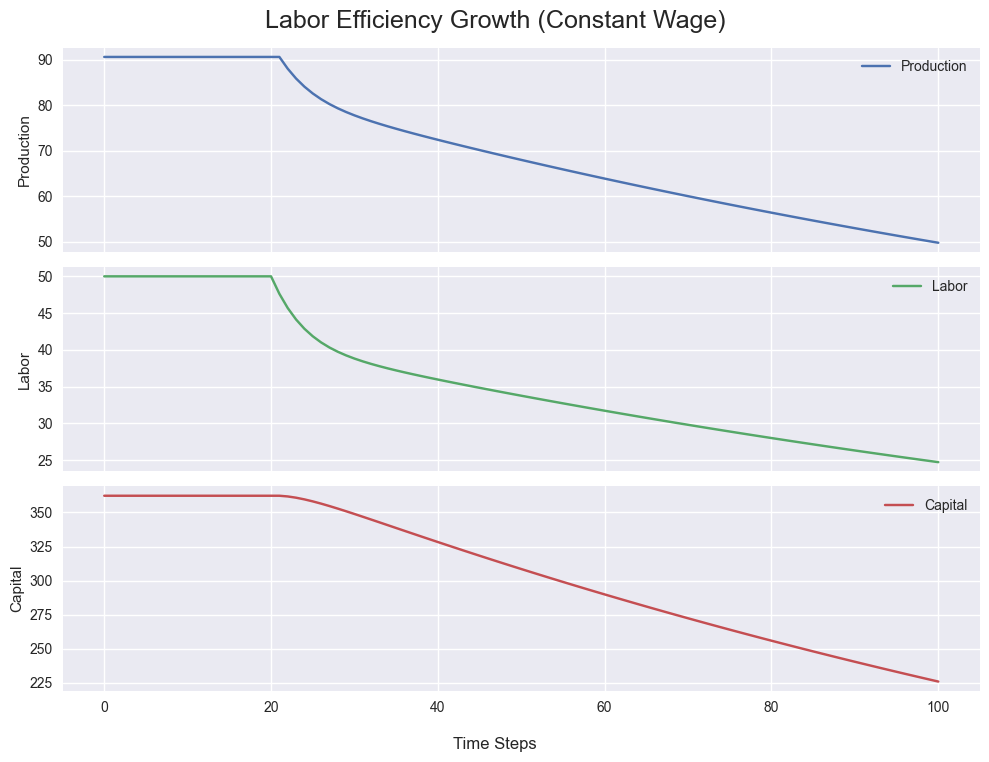

In [ ]:
# labor efficiency growth step at time 50
# constant wage

data = simulate_labor_efficiency_growth(parameters, wage_growth_rate=0.0)
data = {k: v for k, v in data.items() if k in ["Production", "Labor", "Capital"]}
plots.plot_time_data(
    data, title="Labor Efficiency Growth (Constant Wage)", separate=True
)
plt.show()

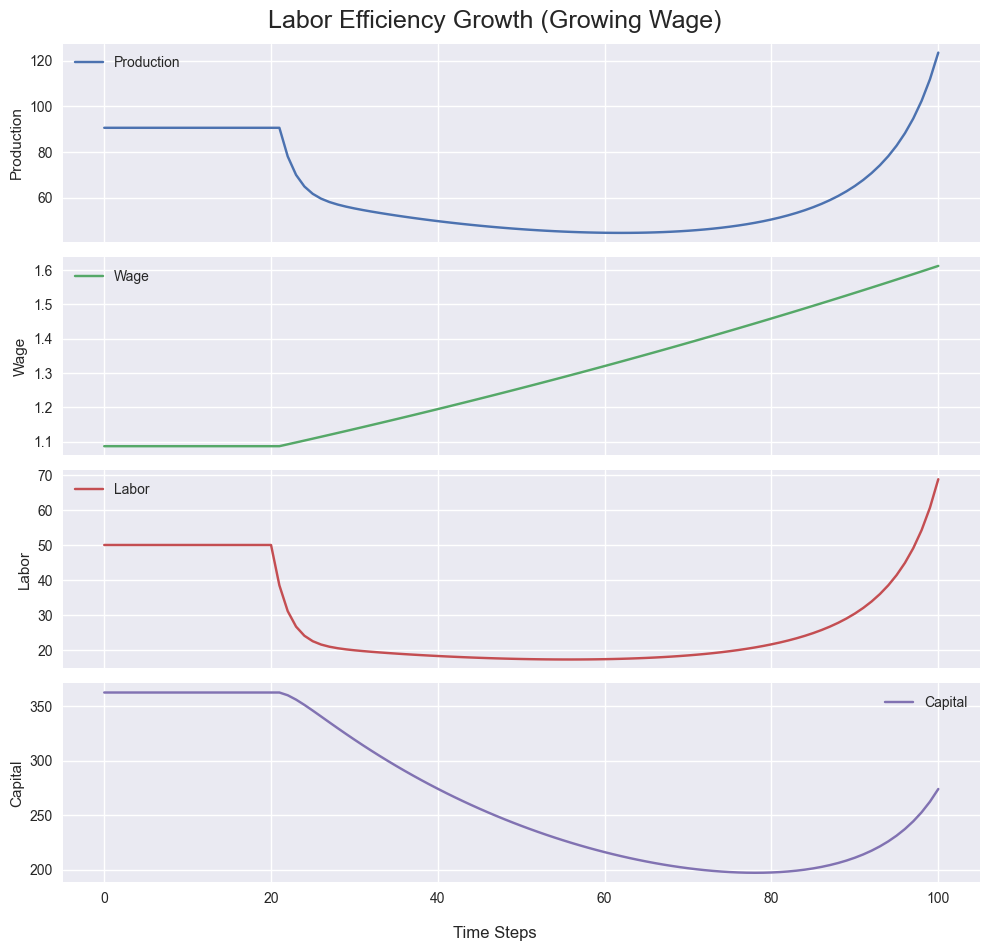

In [ ]:
# growing wage.
# In this case wage growth is exogenous and not moderated by production, I.e, companies can pay more than they produce. This is not a realistic assumption,
# but over a short time frame it can demonstrate that increased wages over time can lead to a recovering economy after a labor efficiency shock.

data = simulate_labor_efficiency_growth(
    parameters, wage_growth_rate=0.005, labor_efficiency_growth_rate=0.3
)
plots.plot_time_data(
    data, title="Labor Efficiency Growth (Growing Wage)", separate=True
)
plt.show()